
# Домашнє завдання: Інтеграція Python та SQL: запити даних

Це ДЗ передбачене під виконання на локальній машині. Виконання з Google Colab буде суттєво ускладнене.

## Підготовка
1. Переконайтесь, що у вас встановлены необхідні бібліотеки:
   ```bash
   pip install sqlalchemy pymysql pandas matplotlib seaborn python-dotenv
   ```

2. Створіть файл `.env` з параметрами підключення до бази даних classicmodels. Базу даних ви можете отримати через

  - docker-контейнер згідно існтрукції в [документі](https://www.notion.so/hannapylieva/Docker-1eb94835849480c9b2e7f5dc22ee4df9), також відео інструкції присутні на платформі - уроки "MySQL бази, клієнт для роботи з БД, Docker і ChatGPT для запитів" та "Як встановити Docker для роботи з базами даних без терміналу"
  - або встановивши локально цю БД - для цього перегляньте урок "Опціонально. Встановлення MySQL та  БД Сlassicmodels локально".
  
  Приклад `.env` файлу ми створювали в лекції. Ось його обовʼязкове наповнення:
    ```
    DB_HOST=your_host
    DB_PORT=3306 або 3307 - той, який Ви налаштували
    DB_USER=your_username
    DB_PASSWORD=your_password
    DB_NAME=classicmodels
    ```
  Якщо ви створили цей файл під час перегляду лекції - **новий створювати не треба**. Замініть лише назву БД, або пропишіть назву в коді створення підключення (замість отримання назви цільової БД зі змінних оточення). Але переконайтесь, що до `.env` файл лежить в тій самій папці, що і цей ноутбук.

  **УВАГА!** НЕ копіюйте скрит для **створення** `.env` файлу. В лекції він наводиться для прикладу. І давалось пояснення, що в реальних проєктах ми НІКОЛИ не пишемо доступи до бази в коді. Копіювання скрипта для створення `.env` файлу сюди в ДЗ буде вважатись грубою помилкою і ми зніматимемо бали.

3. Налаштуйте підключення через SQLAlchemy до БД за прикладом в лекції.

Рекомендую вивести (відобразити) змінну engine після створення. Вона має бути не None! Якщо None - значить у Вас не підтягнулись налаштування з .env файла.

Ви також можете налаштувати параметри підключення до БД без .env файла, просто прописавши текстом в відповідних місцях. Це - не рекомендований підхід.


In [1]:
# Встановлюємо необхідні бібліотеки для роботи з БД
!pip install sqlalchemy pymysql pandas numpy matplotlib seaborn python-dotenv --quiet

In [2]:
# Імпортуємо необхідні бібліотеки
import os
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

In [3]:
# Завантажуємо параметри підключення з файлу .env
load_dotenv(override=True)

True

In [4]:
# Створюємо підключення до БД через SQLAlchemy
def create_connection():
    host = os.getenv("DB_HOST")
    port = os.getenv("DB_PORT")
    user = os.getenv("DB_USER")
    password = os.getenv("DB_PASSWORD")
    database = os.getenv("DB_NAME")

    # Створюємо рядок підключення
    connection_string = f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}"

    # Створюємо engine
    engine = create_engine(
        connection_string,
        pool_size=2,
        max_overflow=20,
        pool_pre_ping=True,
        echo=False)

    # Перевіряємо підключення
    try:
        with engine.connect() as conn:
            conn.execute(text("SELECT 1"))

        print("Підключення до БД успішне!")
        print(f"Engine створено: {engine is not None}")

        return engine

    except Exception as e:
        print(f"Помилка підключення: {e}")
        return None


# Створюємо підключення
engine = create_connection()

Підключення до БД успішне!
Engine створено: True


### Завдання 1: Простий запит (1 бал)

Ми працюємо з БД Classicmodels.

**Виведіть інформацію про продукти на складі** з наступними полями:
- назва продукту (productName)
- лінійка продукту (productLine)
- кількість на складі (quantityInStock)
- ціна закупки (buyPrice)

Зчитайте дані з БД з допомогою `pd.read_sql()` з SQLAlchemy engine, який ви створили на етапі підготовки.

Виведіть перші 10 продуктів, відсортованих за кількістю на складі (від більшої кількості до меншої).

In [5]:
# Отримуємо перші 10 продуктів за кількістю на складі
query = """
SELECT productName, productLine, quantityInStock, buyPrice
FROM products
ORDER BY quantityInStock DESC
LIMIT 10
"""
df_products = pd.read_sql(query, engine)
display(df_products)

,productName,productLine,quantityInStock,buyPrice
0,2002 Suzuki XREO,Motorcycles,9997,66.27
1,1995 Honda Civic,Classic Cars,9772,93.89
2,America West Airlines B757-200,Planes,9653,68.80
3,2002 Chevy Corvette,Classic Cars,9446,62.11
4,1932 Model A Ford J-Coupe,Vintage Cars,9354,58.48
5,1982 Ducati 996 R,Motorcycles,9241,24.14
6,1912 Ford Model T Delivery Wagon,Vintage Cars,9173,46.91
7,1976 Ford Gran Torino,Classic Cars,9127,73.49
8,1968 Dodge Charger,Classic Cars,9123,75.16
9,1965 Aston Martin DB5,Classic Cars,9042,65.96



### Завдання 2: Аналітика замовлень за 2004 рік (3 бали)

**Виведіть детальну інформацію про замовлення за 2004 рік** з наступними полями:
- Номер замовлення (orderNumber)
- Дата замовлення (orderDate)
- Статус замовлення (status)
- Ім'я клієнта (customerName)
- Країна клієнта (country)
- Загальна сума замовлення (сума всіх orderdetails.quantityOrdered * orderdetails.priceEach)

Використайте JOIN для об'єднання таблиць orders, customers, orderdetails. Додайте параметризацію за роком (тільки замовлення за 2004 рік).

Використайте `text()` та named parameters для формування запиту з SQLAlchemy.

Після отримання даних з БД проведіть обчислення з Python та напишіть висновки:
1. Побудуйте стовпчасту діаграму суми замовлень по країнам і напишіть, в якій країні найбільша сума замовлень за 2004 рік.
2. В країні з найбільшою кількістю замовлень знайдіть клієнта, який зробив замовлень на найбільшу суму і виведіть імʼя цього клієнта, на яку суму він зробив замовлень і який % від всіх замовлень в цій країні становить його сума замовлень за рік.

In [6]:
# Отримуємо детальну інформацію про замовлення за 2004 рік
orders_query = text("""
SELECT o.orderNumber, 
       o.orderDate, 
       o.status, 
       c.customerName, 
       c.country,
    SUM(od.quantityOrdered * od.priceEach) AS orderAmount
FROM orders o
JOIN customers c
    ON o.customerNumber = c.customerNumber
JOIN orderdetails od
    ON o.orderNumber = od.orderNumber
WHERE YEAR(o.orderDate) = :year
GROUP BY o.orderNumber, 
         o.orderDate, 
         o.status, 
         c.customerName, 
         c.country
ORDER BY o.orderDate
""")
df_orders = pd.read_sql(orders_query,
                        engine,
                         params={"year": 2004}
)

# Прибираємо зайві пробіли в назвах країн
df_orders["country"] = df_orders["country"].str.strip()

display(df_orders)

,orderNumber,orderDate,status,customerName,country,orderAmount
0,10208,2004-01-02,Shipped,"Saveley & Henriot, Co.",France,49614.72
1,10209,2004-01-09,Shipped,"Men 'R' US Retailers, Ltd.",USA,21053.69
2,10210,2004-01-12,Shipped,Osaka Souveniers Co.,Japan,47177.59
3,10211,2004-01-15,Shipped,Auto Canal+ Petit,France,49165.16
4,10212,2004-01-16,Shipped,Euro+ Shopping Channel,Spain,59830.55
...,...,...,...,...,...,...
146,10357,2004-12-10,Shipped,Mini Gifts Distributors Ltd.,USA,40676.26
147,10358,2004-12-10,Shipped,Euro+ Shopping Channel,Spain,44185.46
148,10359,2004-12-15,Shipped,Reims Collectables,France,32600.61
149,10360,2004-12-16,Shipped,Kelly's Gift Shop,New Zealand,52166.00


,country,orderAmount
19,USA,1526499.65
6,France,506660.01
15,Spain,439881.84
18,UK,238193.93
11,New Zealand,233362.27
0,Australia,204213.18
9,Italy,179108.40
7,Germany,133831.70
10,Japan,133326.77
3,Canada,123404.03


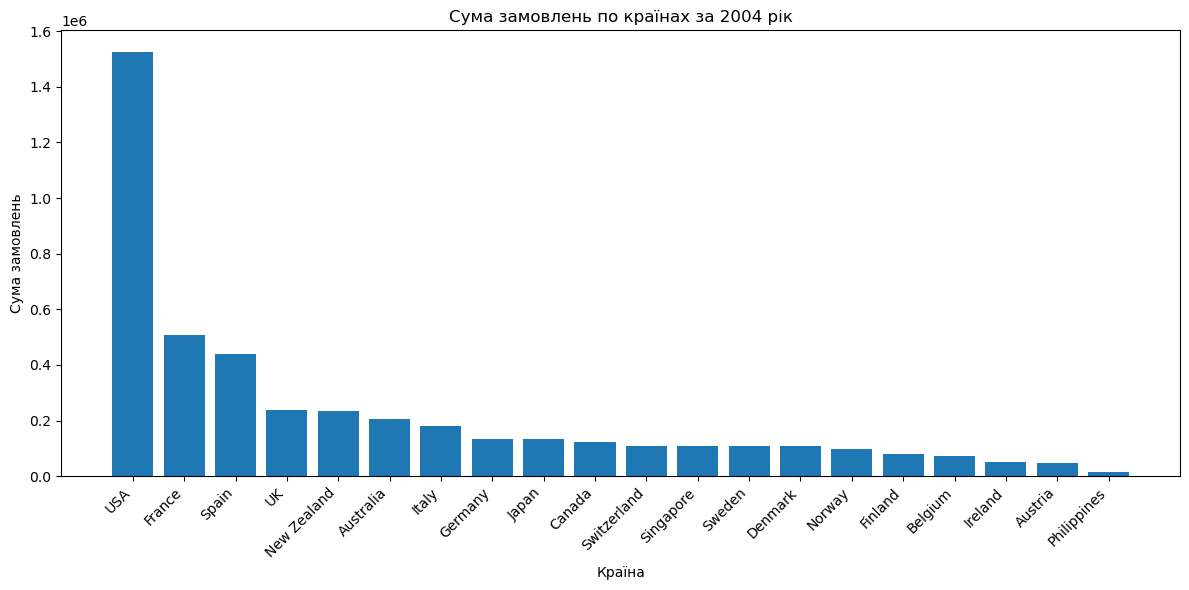

Найбільша сума замовлень у 2004 році — USA: 1,526,499.65


In [7]:
# 1.Рахуємо суму замовлень по країнах та будуємо діаграму
import matplotlib.pyplot as plt
country_sales = ( df_orders.groupby("country", as_index=False)["orderAmount"]
                  .sum()
                  .sort_values("orderAmount", ascending=False) )
country_sales["orderAmount"] = country_sales["orderAmount"].round(2)
display(country_sales)

plt.figure(figsize=(12, 6))
plt.bar(country_sales["country"], country_sales["orderAmount"])
plt.title("Сума замовлень по країнах за 2004 рік")
plt.xlabel("Країна")
plt.ylabel("Сума замовлень")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

top_country = country_sales.iloc[0]

print( f"Найбільша сума замовлень у 2004 році — "
       f"{top_country['country']}: {top_country['orderAmount']:,.2f}" )

**Висновок: Найбільша сума замовлень за 2004 рік припадає на USA — 1 526 499,65.**

In [8]:
# 2.Знаходимо країну з найбільшою кількістю замовлень
top_country_orders = df_orders["country"].value_counts().idxmax()

# Відбираємо замовлення цієї країни
country_data = df_orders[df_orders["country"] == top_country_orders]

# Рахуємо суму замовлень по клієнтах
customer_sales = (
    country_data.groupby("customerName", as_index=False)["orderAmount"]
    .sum()
    .sort_values("orderAmount", ascending=False)
)

# Знаходимо клієнта з найбільшою сумою замовлень
top_customer = customer_sales.iloc[0]

# Рахуємо загальну суму замовлень країни
country_total = country_data["orderAmount"].sum()

# Рахуємо частку клієнта у загальній сумі країни
customer_share = top_customer["orderAmount"] / country_total * 100

print(f"Країна з найбільшою кількістю замовлень: {top_country_orders}")
print(f"Клієнт з найбільшою сумою замовлень: {top_customer['customerName']}")
print(f"Сума замовлень клієнта: {top_customer['orderAmount']:,.2f}")
print(f"Частка суми клієнта від загальної суми замовлень країни: {customer_share:.2f}%")

Країна з найбільшою кількістю замовлень: USA
Клієнт з найбільшою сумою замовлень: Mini Gifts Distributors Ltd.
Сума замовлень клієнта: 231,562.53
Частка суми клієнта від загальної суми замовлень країни: 15.17%


**Висновок:Найбільшу кількість замовлень має USA.Серед клієнтів цієї країни найбільшу суму замовлень має Mini Gifts Distributors Ltd. - 231 562,53, що становить 15,17% від загальної суми замовлень USA.**


### Завдання 3: Аналітичний запит - Топ продуктів по продажах (6 балів)

В цьому завданні ви отримуєте 1 бал за правильний SQL запит і по 1 балу за кожне завдання з Python.

**Проведіть аналіз прибутковості продуктів** та для цього дістаньте з БД інформацію з наступними полями:
- Назва продукту
- Лінійка продукту (productLine)
- Загальний дохід з цього продукту (сума quantity * priceEach)
- Ранг продукту по доходу (тобто яке місце посідає цей продукт за доходом серед усіх продуктів в нашому магазині)
- Який відсоток від загального доходу компанії складає цей продукт
- Різниця з середнім доходом по лінійці продукту (в %)

Відсортуйте дані за спаданням значень колонки "Який відсоток від загального доходу компанії складає цей продукт".

При створенні SQL запиту вам можуть стати в нагоді:
- **CTE** для розрахунку доходу по кожному продукту
- **Віконні функції** для ранжування та порівняння з середнім

Після отримання даних з БД проведіть обчислення (де треба) з Python та напишіть висновки:
1. Який відсоток від загального доходу складає ТОП1 продукт і що це за продукт?
2. Створіть стовпчикову діаграму топ-10 продуктів по доходу. В скільки разів відрізняється сумарний дохід за ТОП1 продуктом від 10го продукту за сумою доходу?
3. Створіть кругову діаграму розподілу доходу по лініях продуктів. Який відсоток від всіх продажів становлять продажі за ТОП2 лініями сумарно?
4. Розрахуйте та виведіть за принципом Парето (80/20) - скільки продуктів дають 80% доходу. Тобто нам треба знайти кількість продуктів сумарне значення "відсотку від загального доходу компанії", яких складає 80 починаючи з продукту з найбільшим цим відсотком.
5. Зробіть ще будь-яке аналітичне дослідження, яке дасть нам більше розуміння наших даних, що ми дістали в БД в цьому завданні. Сформоване питання до даних і обчислення має бути обовʼязково. Візуалізація - опціонально.

Візуалізацію можна створювати з будь-якою бібліотекою на ваш вибір.

In [9]:
# Аналізуємо дохід та прибутковість усіх продуктів
products_query = text("""
WITH product_revenue AS ( SELECT p.productName,
                                 p.productLine,
        COALESCE(SUM(od.quantityOrdered * od.priceEach), 0) AS totalRevenue
    FROM products p
    LEFT JOIN orderdetails od
        ON p.productCode = od.productCode
    GROUP BY p.productName,
             p.productLine
   )

SELECT productName,
       productLine,
    ROUND(totalRevenue, 2) AS totalRevenue,
    RANK() OVER (
                ORDER BY totalRevenue DESC
             ) AS revenueRank,
    ROUND( totalRevenue / SUM(totalRevenue) OVER () * 100, 2
      ) AS companyRevenuePercent,
    
    ROUND((totalRevenue / AVG(totalRevenue) OVER (
                                               PARTITION BY productLine) - 1) * 100, 2
     ) AS productLineAvgDifferencePercent

FROM product_revenue
ORDER BY companyRevenuePercent DESC
""")

df_products_analysis = pd.read_sql(products_query, engine)

display(df_products_analysis)

,productName,productLine,totalRevenue,revenueRank,companyRevenuePercent,productLineAvgDifferencePercent
0,1992 Ferrari 360 Spider red,Classic Cars,276839.98,1,2.88,172.97
1,2001 Ferrari Enzo,Classic Cars,190755.86,2,1.99,88.09
2,1952 Alpine Renault 1300,Classic Cars,190017.96,3,1.98,87.36
3,2003 Harley-Davidson Eagle Drag Bike,Motorcycles,170686.00,4,1.78,97.87
4,1968 Ford Mustang,Classic Cars,161531.48,5,1.68,59.27
...,...,...,...,...,...,...
105,1958 Chevy Corvette Limited Edition,Classic Cars,31627.96,106,0.33,-68.81
106,1982 Lamborghini Diablo,Classic Cars,30972.87,107,0.32,-69.46
107,1936 Mercedes Benz 500k Roadster,Vintage Cars,29763.39,108,0.31,-60.26
108,1939 Chevrolet Deluxe Coupe,Vintage Cars,28052.94,109,0.29,-62.55


In [10]:
# 1.Визначаємо TOP1 продукт за доходом
top_product = df_products_analysis.iloc[0]

print(f"TOP1 продукт: {top_product['productName']}")
print(f"Загальний дохід: {top_product['totalRevenue']:,.2f}")
print(f"Частка від загального доходу компанії: {top_product['companyRevenuePercent']:.2f}%")

TOP1 продукт: 1992 Ferrari 360 Spider red
Загальний дохід: 276,839.98
Частка від загального доходу компанії: 2.88%


**Висновок: Найбільший дохід має1992 Ferrari 360 Spider red — 276 839,98.  
Його частка в загальному доході компанії становить 2,88%.**

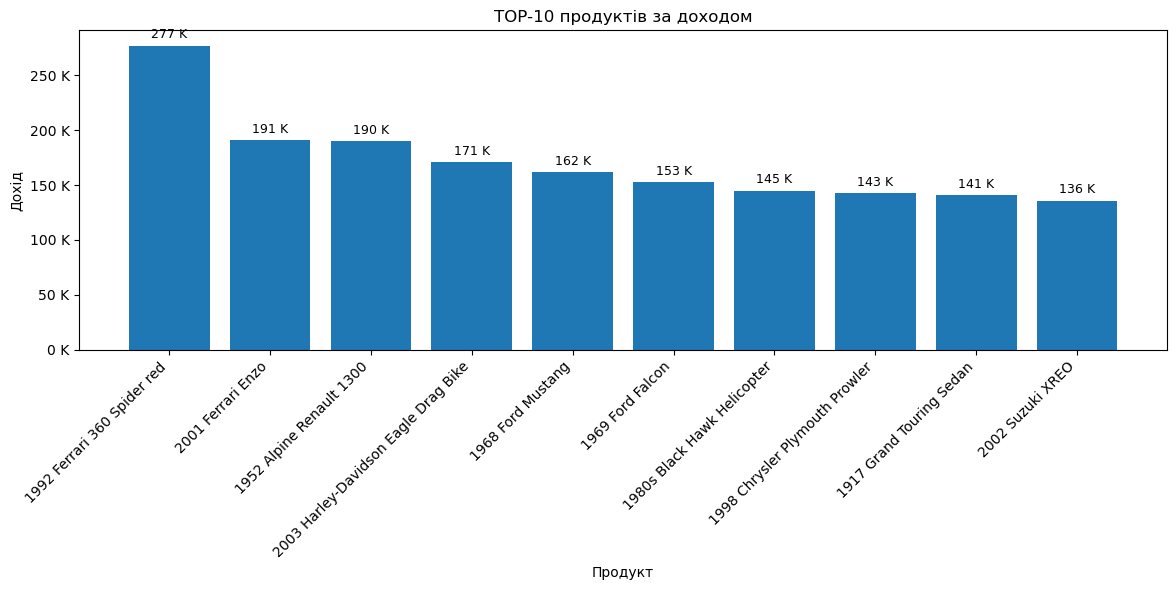

Дохід TOP1 продукту: 276,839.98
Дохід 10-го продукту: 135,767.03
Дохід TOP1 продукту у 2.04 раза перевищує дохід 10-го продукту


In [11]:
# 2.Будуємо діаграму TOP-10 продуктів за доходом
top10_products = df_products_analysis.head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(top10_products["productName"], top10_products["totalRevenue"])
labels = [f"{value / 1000:.0f} K" for value in top10_products["totalRevenue"]]
plt.bar_label(bars, labels=labels, padding=3, fontsize=9)
plt.title("TOP-10 продуктів за доходом")
plt.xlabel("Продукт")
plt.ylabel("Дохід")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
from matplotlib.ticker import FuncFormatter
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x / 1000:.0f} K") )
plt.show()

# Порівнюємо дохід TOP1 і 10-го продукту за доходом
top1_revenue = top10_products.iloc[0]["totalRevenue"]
top10_revenue = top10_products.iloc[9]["totalRevenue"]

revenue_difference = top1_revenue / top10_revenue

print(f"Дохід TOP1 продукту: {top1_revenue:,.2f}")
print(f"Дохід 10-го продукту: {top10_revenue:,.2f}")
print(f"Дохід TOP1 продукту у {revenue_difference:.2f} раза перевищує дохід 10-го продукту")

**Висновок: Дохід TOP-1 продукту практично в 2 раза(2,04) перевищує дохід 10-го продукту. Це показує, що перший продукт помітно випереджає інші товари з TOP-10**

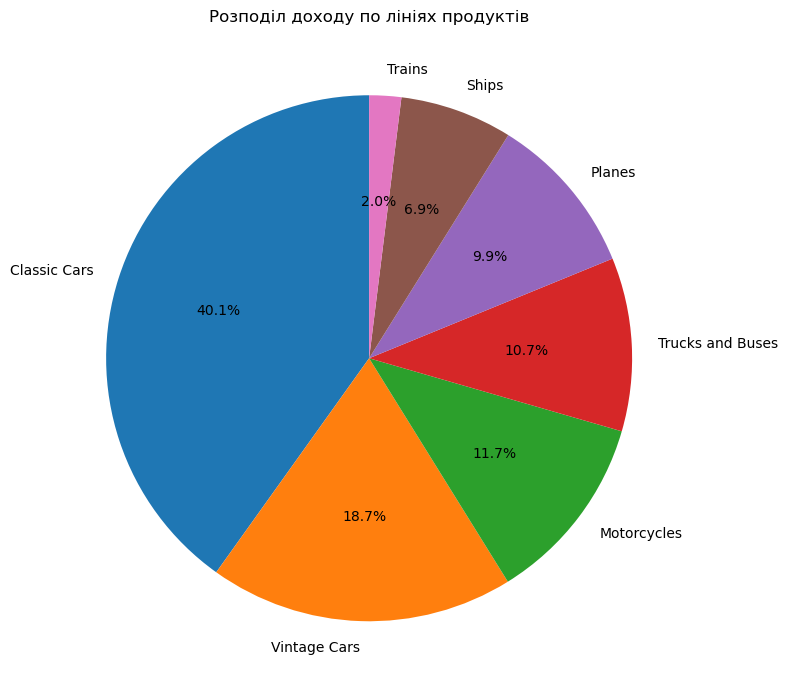

TOP-2 лінії продуктів: Classic Cars та Vintage Cars
Їх сумарна частка від усіх продажів: 58.84%


In [12]:
# 3.Будуємо кругову діаграму розподілу доходу по лініях продуктів
productline_sales = (
    df_products_analysis.groupby("productLine", as_index=False)["totalRevenue"]
    .sum()
    .sort_values("totalRevenue", ascending=False)
 )
plt.figure(figsize=(8, 8))
plt.pie( productline_sales["totalRevenue"],
         labels=productline_sales["productLine"],
         autopct="%1.1f%%",
         startangle=90
  )
plt.title("Розподіл доходу по лініях продуктів")
plt.tight_layout()
plt.show()

# Рахуємо частку TOP-2 ліній у загальному доході
top2_revenue = productline_sales.head(2)["totalRevenue"].sum()
total_revenue = productline_sales["totalRevenue"].sum()

top2_share = top2_revenue / total_revenue * 100

print(f"TOP-2 лінії продуктів: {productline_sales.iloc[0]['productLine']} та {productline_sales.iloc[1]['productLine']}")
print(f"Їх сумарна частка від усіх продажів: {top2_share:.2f}%")

**Висновок: Найбільшу частку доходу формують Classic Cars та Vintage Cars. Разом вони дають 58,84% загального доходу компанії.**

In [13]:
# 4. Визначаємо, скільки продуктів формують 80% доходу
df_pareto = df_products_analysis.copy()
df_pareto = df_pareto.sort_values("totalRevenue", ascending=False)

# Рахуємо точну частку кожного продукту в загальному доході
df_pareto["revenuePercent"] = (
    df_pareto["totalRevenue"] /
    df_pareto["totalRevenue"].sum() * 100
)

# Рахуємо накопичену частку доходу
df_pareto["cumulativePercent"] = df_pareto["revenuePercent"].cumsum()

# Знаходимо кількість продуктів, необхідних для досягнення 80%
pareto_count = (df_pareto["cumulativePercent"] < 80).sum() + 1

# Накопичена частка доходу на цьому продукті
pareto_revenue = df_pareto.iloc[pareto_count - 1]["cumulativePercent"]

# Частка цих продуктів від загальної кількості продуктів
pareto_products_percent = pareto_count / len(df_pareto) * 100

print(f"Кількість продуктів, які формують приблизно 80% доходу: {pareto_count}")
print(f"Накопичена частка доходу: {pareto_revenue:.2f}%")
print(f"Це {pareto_products_percent:.2f}% від усіх продуктів")

Кількість продуктів, які формують приблизно 80% доходу: 72
Накопичена частка доходу: 80.43%
Це 65.45% від усіх продуктів


**Висновок: За результатами розрахунку 72 продукти формують близько 80% загального доходу компанії, сумарна частка доходу за ціми продуктами становить 80,43%**

In [14]:
# 5.«Яка продуктова лінійка має найбільший середній дохід на один продукт і на скільки % він перевищує середній дохід продукту по всій компанії?»

# Аналізуємо середній дохід на один продукт по продуктових лінійках
productline_analysis = ( df_products_analysis.groupby("productLine", as_index=False)
                      .agg( productCount=("productName", "count"),
                            totalRevenue=("totalRevenue", "sum"),
                            avgRevenue=("totalRevenue", "mean"))
    .sort_values("avgRevenue", ascending=False)
)
productline_analysis["avgRevenue"] = productline_analysis["avgRevenue"].round(2)
productline_analysis["totalRevenue"] = productline_analysis["totalRevenue"].round(2)
display(productline_analysis)

# Знаходимо лінійку з найбільшим середнім доходом
top_line = productline_analysis.iloc[0]

# Рахуємо середній дохід одного продукту по всій компанії
company_avg_revenue = df_products_analysis["totalRevenue"].mean()

# Рахуємо різницю у відсотках
difference_percent = ((top_line["avgRevenue"] / company_avg_revenue - 1) * 100)

print(f"Найвищий середній дохід має лінійка: {top_line['productLine']}")
print(f"Середній дохід на продукт: {top_line['avgRevenue']:,.2f}")
print(f"Середній дохід продукту по компанії: {company_avg_revenue:,.2f}")
print(f"Перевищення середнього показника компанії: {difference_percent:.2f}%")

,productLine,productCount,totalRevenue,avgRevenue
0,Classic Cars,38,3853922.49,101419.01
5,Trucks and Buses,11,1024113.57,93101.23
1,Motorcycles,13,1121426.12,86263.55
2,Planes,12,954637.54,79553.13
6,Vintage Cars,24,1797559.63,74898.32
3,Ships,9,663998.34,73777.59
4,Trains,3,188532.92,62844.31


Найвищий середній дохід має лінійка: Classic Cars
Середній дохід на продукт: 101,419.01
Середній дохід продукту по компанії: 87,310.82
Перевищення середнього показника компанії: 16.16%


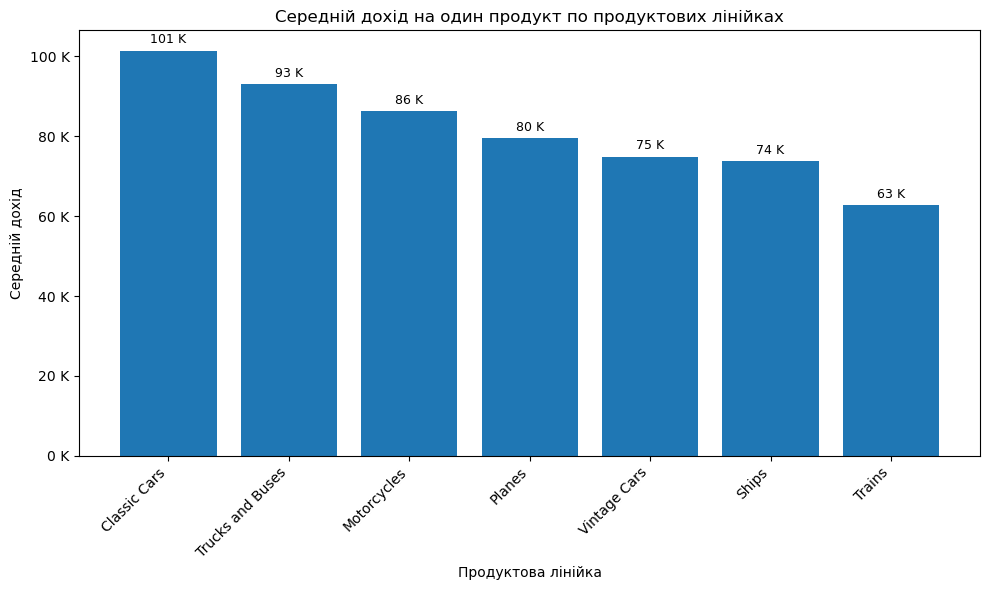

In [15]:
# Будуємо діаграму середнього доходу по продуктових лінійках
from matplotlib.ticker import FuncFormatter
plt.figure(figsize=(10, 6))
bars = plt.bar( productline_analysis["productLine"],
                productline_analysis["avgRevenue"])
# Додаємо значення над стовпчиками у форматі K
labels = [f"{value / 1000:.0f} K" for value in productline_analysis["avgRevenue"]]
plt.bar_label(bars, labels=labels, padding=3, fontsize=9)

plt.title("Середній дохід на один продукт по продуктових лінійках")
plt.xlabel("Продуктова лінійка")
plt.ylabel("Середній дохід")
# Форматуємо вісь Y у тисячах
plt.gca().yaxis.set_major_formatter(
             FuncFormatter(lambda x, pos: f"{x / 1000:.0f} K"))

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Висновок: Найвищий середній дохід на один продукт має лінійка Classic Cars - 101 419,01. Це на 16,16% вище середнього доходу одного продукту по компанії.**

### ОПЦІОНАЛЬНО. Завдання 4: Аналітичний запит - Динаміка продажів по місяцях (8 балів)

**Проведіть аналіз динаміки продажів по місяцях** та для цього дістаньте з бази інформацію з наступними полями:
- Рік та місяць замовлень
- Кількість замовлень за цей рік-місяць
- Загальний дохід (quantityOrdered * priceEach) за цей рік-місяць
- На який % ми зросли за доходом порівняно з попереднім місяцем
- Накопичувальний дохід до цього місяця за рік
- Ковзне середнє доходу за 3 місяці
- Ранг цього місяця за доходом

Використайте:
- **CTE** для агрегації продажів по місяцях
- **Віконні функції** для розрахунку:
  - Зростання доходу порівняно з попереднім місяцем (LAG)
  - Накопичувальний дохід за рік
  - Ковзне середнє доходу за 3 місяці (AVG OVER)
  - Ранжування місяців за доходом (RANK)

Після отримання даних з БД побудуйте наступні графіки і напишіть коротко, які висновки з них можна зробити.
1. Створіть лінійний графік доходу по місяцях. Чи є тред до зростання в даних?
2. Створіть графік місяць-до-місяця зростання у відсотках.
3. Створіть heatmap сезонності (місяць vs рік)
4. Відобразіть козвне середнє разом з динамікою продажів.
5. Розрахуйте кореляцію між кількістю замовлень та середнім чеком та побудуйте графік розсіювання між цими змінними. Чи є лінійна залежність?

Очікуваний результат кожного графіку - нижче.
В першому графіку я додала лінію тренду аби показати тренд. Вам її додавати не треба.

**ВАЖЛИВО!** Якщо ви захочете назвати одну з колонок .`year_month` - запит не буде працювати, бо year_month - [зарезервоване слово](https://stackoverflow.com/questions/34906190/mysql-using-year-month) в SQL і сприймається як команда. Треба використати іншу назву для відповідної колонки.


In [16]:
# 1.Аналізуємо динаміку продажів по місяцях
monthly_sales_query = text("""
WITH monthly_sales AS (
    SELECT YEAR(o.orderDate) AS salesYear,
           MONTH(o.orderDate) AS salesMonth,
           DATE_FORMAT(o.orderDate, '%Y-%m') AS yearMonth,
           COUNT(DISTINCT o.orderNumber) AS ordersCount,
           SUM(od.quantityOrdered * od.priceEach) AS totalRevenue
    FROM orders o
    JOIN orderdetails od
        ON o.orderNumber = od.orderNumber
        WHERE o.status <> 'Cancelled'   # Виключаємо скасовані замовлення
    GROUP BY YEAR(o.orderDate),
          MONTH(o.orderDate),
          DATE_FORMAT(o.orderDate, '%Y-%m')),
monthly_analytics AS (SELECT salesYear,
                             salesMonth,
                             yearMonth,
                             ordersCount,
                             totalRevenue,
         LAG(totalRevenue) OVER ( ORDER BY salesYear, salesMonth) AS previousMonthRevenue,
        SUM(totalRevenue) OVER ( PARTITION BY salesYear
                                 ORDER BY salesMonth
                                 ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) 
                                 AS cumulativeRevenue,
        AVG(totalRevenue) OVER (ORDER BY salesYear, salesMonth
                                ROWS BETWEEN 2 PRECEDING AND CURRENT ROW)
                                AS movingAvg3Months,
       RANK() OVER (ORDER BY totalRevenue DESC) AS revenueRank
     FROM monthly_sales
 )
SELECT yearMonth,
       ordersCount,
       ROUND(totalRevenue, 2) AS totalRevenue,
       ROUND((totalRevenue / previousMonthRevenue - 1) * 100,2) 
       AS revenueGrowthPercent,

    ROUND(cumulativeRevenue, 2) AS cumulativeRevenue,
    ROUND(movingAvg3Months, 2) AS movingAvg3Months,
    revenueRank
FROM monthly_analytics
ORDER BY salesYear, salesMonth
""")

df_monthly_sales = pd.read_sql(monthly_sales_query, engine)
display(df_monthly_sales)

,yearMonth,ordersCount,totalRevenue,revenueGrowthPercent,cumulativeRevenue,movingAvg3Months,revenueRank
0,2003-01,5,116692.77,NaN,116692.77,116692.77,29
1,2003-02,3,128403.64,10.04,245096.41,122548.21,28
2,2003-03,6,160517.14,25.01,405613.55,135204.52,26
3,2003-04,7,185848.59,15.78,591462.14,158256.46,23
4,2003-05,6,179435.55,-3.45,770897.69,175267.09,24
5,2003-06,7,150470.77,-16.14,921368.46,171918.30,27
6,2003-07,7,201940.36,34.21,1123308.82,177282.23,21
7,2003-08,5,178257.11,-11.73,1301565.93,176889.41,25
8,2003-09,8,236697.85,32.78,1538263.78,205631.77,17
9,2003-10,17,470169.12,98.64,2008432.90,295041.36,4


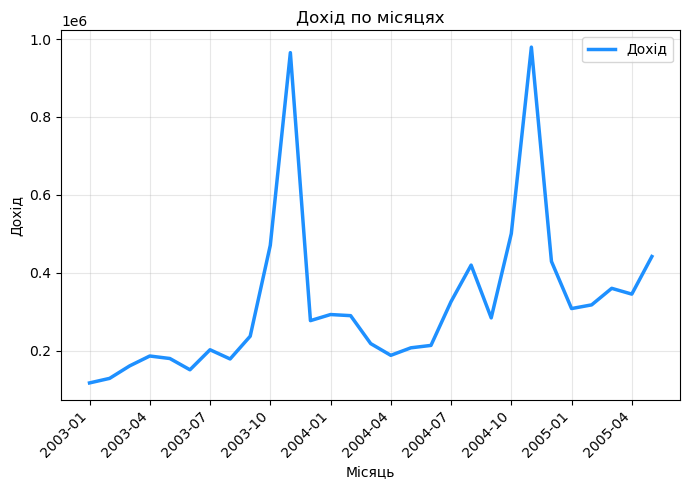

In [17]:
# 1.Будуємо лінійний графік доходу по місяцях 
from matplotlib.ticker import FuncFormatter
plt.figure(figsize=(7, 5))
plt.plot( df_monthly_sales["yearMonth"],
          df_monthly_sales["totalRevenue"],
          color="dodgerblue",
          linewidth=2.5,
          label="Дохід")
plt.title("Дохід по місяцях")
plt.xlabel("Місяць")
plt.ylabel("Дохід")
plt.ticklabel_format(style="sci",
                     axis="y",
                     scilimits=(6, 6))
# Показуємо не всі підписи місяців, щоб графік був компактний
plt.xticks( range(0, len(df_monthly_sales), 3),
            df_monthly_sales["yearMonth"].iloc[::3],
            rotation=45,
            ha="right")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Висновок: Дохід по місяцях змінюється нерівномірно. Найбільші піки спостерігаються у листопаді 2003 та 2004 років майже 1 млн. після чого відбувається різке зниження. Загалом наприкінці періоду рівень доходу вищий, ніж на початку, але стабільного щомісячного зростання немає**

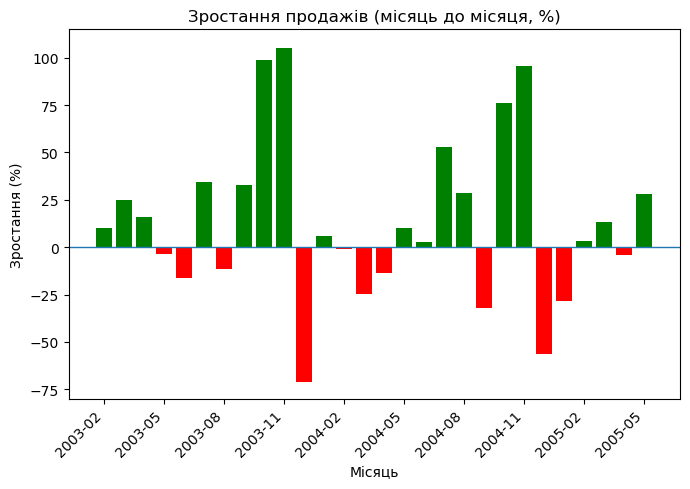

In [18]:
# 2. Будуємо графік зростання продажів місяць до місяця
growth_data = df_monthly_sales.dropna(subset=["revenueGrowthPercent"]).copy()
# Зелений — зростання, червоний — падіння
colors = ["green" if x >= 0 else "red"
           for x in growth_data["revenueGrowthPercent"]]
plt.figure(figsize=(7, 5))
plt.bar( growth_data["yearMonth"],
         growth_data["revenueGrowthPercent"],
         color=colors)
plt.axhline(0, linewidth=1)  # Нульова лінія
plt.title("Зростання продажів (місяць до місяця, %)")
plt.xlabel("Місяць")
plt.ylabel("Зростання (%)")

plt.xticks(range(0, len(growth_data), 3),
           growth_data["yearMonth"].iloc[::3],
           rotation=45,
           ha="right")
plt.ylim(-80, 115)  # Межі осі Y 
plt.tight_layout()
plt.show()

**Висновок: Динаміка продажів по місяцях нестабільна, періоди зростання чергуються зі спадом. Найбільше зростання спостерігається наприкінці 2003 та 2004 років, після чого відбувається значне зниження. Така послідовність може свідчити про сезонний характер продажів.**

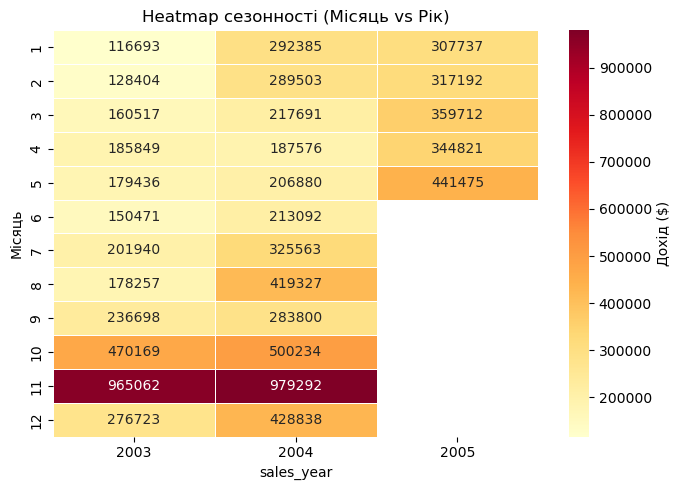

In [19]:
# 3. Heatmap сезонності
import seaborn as sns

# Виділяємо рік і місяць із поля yearMonth
heatmap_data = df_monthly_sales.copy()
heatmap_data["sales_year"] = pd.to_datetime(heatmap_data["yearMonth"]).dt.year
heatmap_data["sales_month"] = pd.to_datetime(heatmap_data["yearMonth"]).dt.month

# Формуємо таблицю для heatmap
pivot_data = heatmap_data.pivot(
    index="sales_month",
    columns="sales_year",
    values="totalRevenue"
)

# Будуємо heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    pivot_data,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Дохід ($)"}
)

plt.title("Heatmap сезонності (Місяць vs Рік)")
plt.xlabel("sales_year")
plt.ylabel("Місяць")
plt.tight_layout()
plt.show()

**Висновок: На heatmap простежується сезонність продажів.Найвищий дохід спостерігається у листопаді 2003 та 2004 років, також підвищені значення характерні для осінньо-зимового періоду. У першій половині року дохід переважно нижчий, тому наприкінці року продажі мають тенденцію до зростання.**

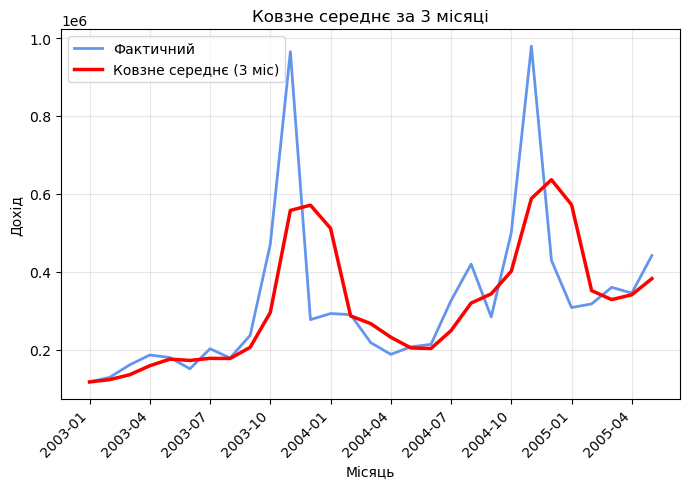

In [20]:
# 4. Відображаємо ковзне середнє разом з динамікою доходу
plt.figure(figsize=(7, 5))
plt.plot( df_monthly_sales["yearMonth"],
          df_monthly_sales["totalRevenue"],
          color="cornflowerblue",
          linewidth=2,
          label="Фактичний")
plt.plot( df_monthly_sales["yearMonth"],
          df_monthly_sales["movingAvg3Months"],
          color="red",
          linewidth=2.5,
          label="Ковзне середнє (3 міс)")
plt.title("Ковзне середнє за 3 місяці")
plt.xlabel("Місяць")
plt.ylabel("Дохід")
# Вісь X кожен третій місяць
plt.xticks(range(0, len(df_monthly_sales), 3),
           df_monthly_sales["yearMonth"].iloc[::3],
           rotation=45,
           ha="right")
# Вісь Y 
plt.ticklabel_format(style="sci",
                     axis="y",
                     scilimits=(6, 6))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Висновок: Ковзне середнє згладжує різкі місячні коливання доходу та краще показує загальну динаміку продажів. Найбільші підйоми спостерігаються наприкінці 2003 та 2004 років при цьому загальний рівень доходу наприкінці періоду вищий ніж на початку.**

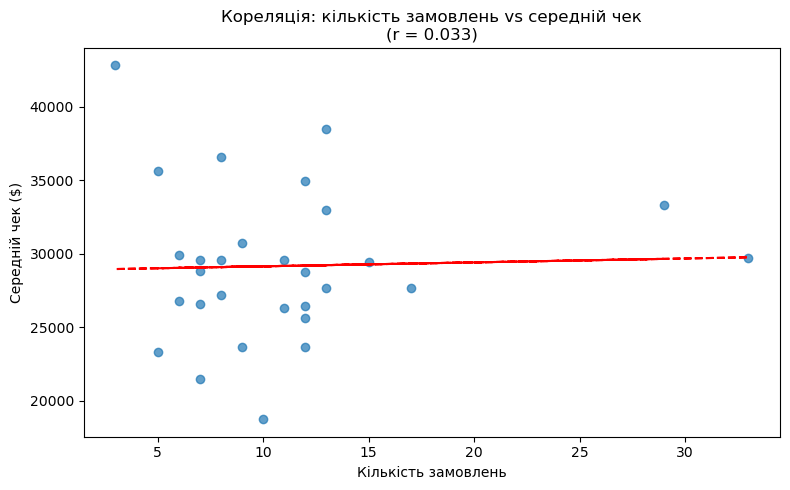

Коефіцієнт кореляції: 0.033


In [21]:
# 5. Кореляція між кількістю замовлень та середнім чеком
correlation_data = df_monthly_sales.copy()

# Розраховуємо середній чек
correlation_data["avgOrderValue"] = (
    correlation_data["totalRevenue"] / correlation_data["ordersCount"]
)

# Розраховуємо коефіцієнт кореляції
correlation = correlation_data["ordersCount"].corr(
    correlation_data["avgOrderValue"]
)

# Будуємо лінію тренду
x = correlation_data["ordersCount"]
y = correlation_data["avgOrderValue"]

trend = np.polyfit(x, y, 1)
trend_line = np.polyval(trend, x)

# Будуємо графік розсіювання
plt.figure(figsize=(8, 5))

plt.scatter(
    x,
    y,
    alpha=0.7
)

plt.plot(
    x,
    trend_line,
    color="red",
    linestyle="--"
)

plt.title(
    f"Кореляція: кількість замовлень vs середній чек\n"
    f"(r = {correlation:.3f})"
)
plt.xlabel("Кількість замовлень")
plt.ylabel("Середній чек ($)")

plt.tight_layout()
plt.show()

print(f"Коефіцієнт кореляції: {correlation:.3f}")

**Висновок: Коефіцієнт кореляції становить 0,033, лінійна залежність між кількістю замовлень та середнім чеком практично відсутня. На графіку є окремі віддалені значення але загального лінійного зв’язку між показниками не спостерігається.**